# Анализ чувствительности к порядку событий

Negative controls показали, что `Shuffled GRU mean` почти не уступает обычному `GRU mean` в оценке удержания. Этот ноутбук разбирает, что именно происходит с пространства эмбеддингов при перемешивании порядка событий.

Главный вопрос: RNN-эмбеддинги действительно чувствительны к порядку событий, и если да, для каких пользователей эта чувствительность сильнее?


## План

1. Загрузить normal `GRU mean` и `Shuffled GRU mean` эмбеддинги из negative controls.
2. Посчитать cosine similarity, L2 distance и relative distance между обычные и перемешанные эмбеддинг одного пользователя.
3. Связать order sensitivity с длиной последовательности, repeat ratio, числом уникальных событий и retention метки.
4. Построить bucket-level профили и графики.
5. Сформулировать, где порядок действительно меняет representation.


## 1. Setup


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '8')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.downstream import build_base_meta, build_baseline_features, build_meta_for_prefix
from src.embedding_analysis import embedding_columns
from src.data import load_prepared_sequences
from src.splits import apply_user_split, load_user_split

sns.set_theme(style='whitegrid', context='notebook')
pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(20)

def to_pandas(df: pl.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(df.to_dicts())

DATA_DIR = PROJECT_ROOT / 'artifacts/data'
NEGATIVE_DIR = PROJECT_ROOT / 'artifacts/negative_controls'
OUT_DIR = PROJECT_ROOT / 'artifacts/order_sensitivity'
FIGURES_DIR = OUT_DIR / 'figures'
for path in [OUT_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
PREFIX_LEN = 150
TOP_K_EVENTS = 10
HORIZONS = {'retention_7d': 7, 'retention_14d': 14}


## 2. Эмбеддинги и metadata

Берём эмбеддинги, уже построенные в `07_negative_controls`: normal `GRU mean` и `Shuffled GRU mean`. Metadata строится по тому же prefix protocol, чтобы анализировать чувствительность к порядку вместе с признаками активности пользователя.


In [2]:
normal_df = pl.read_parquet(NEGATIVE_DIR / 'embeddings' / 'gru_mean.parquet')
shuffled_df = pl.read_parquet(NEGATIVE_DIR / 'embeddings' / 'shuffled_gru_mean.parquet')

normal_cols = embedding_columns(normal_df.columns)
shuffled_cols = embedding_columns(shuffled_df.columns)

prepared = load_prepared_sequences(DATA_DIR)
split = load_user_split(DATA_DIR / 'split.json')
split_prepared = apply_user_split(prepared, split)
train_prepared = split_prepared['train']
split_users_df = pl.read_parquet(DATA_DIR / 'split_users.parquet')
sequence_df = pl.read_parquet(DATA_DIR / 'user_sequences.parquet')

base_meta_df, data_end_ts = build_base_meta(str(DATA_DIR / 'clean_events' / '*.parquet'), prepared.user_ids)
meta_df, _ = build_meta_for_prefix(
    base_meta_df,
    prefix_len=PREFIX_LEN,
    horizons=HORIZONS,
    data_end_ts=data_end_ts,
)
baseline_df, baseline_feature_cols, _ = build_baseline_features(
    prepared,
    train_prepared,
    split_users_df,
    meta_df,
    prefix_len=PREFIX_LEN,
    top_k_events=TOP_K_EVENTS,
    horizons=HORIZONS,
)

metadata_df = (
    baseline_df
    .select(['appmetrica_device_id', 'split', 'prefix_len_feature', 'unique_event_count', 'repeat_ratio', 'prefix_session_count', 'prefix_active_days', *HORIZONS.keys()])
    .join(sequence_df.select(['appmetrica_device_id', 'sequence_len']), on='appmetrica_device_id', how='left')
)

pl.DataFrame({
    'artifact': ['normal_gru_mean', 'shuffled_gru_mean', 'metadata'],
    'num_users': [normal_df.height, shuffled_df.height, metadata_df.height],
    'num_embedding_cols': [len(normal_cols), len(shuffled_cols), 0],
})


artifact,num_users,num_embedding_cols
str,i64,i64
"""normal_gru_mean""",52495,128
"""shuffled_gru_mean""",52495,128
"""metadata""",52495,0


## 3. Пользовательский distance between normal and shuffled эмбеддинги

Сравниваем эмбеддинг одного и того же пользователя до и после перемешивания порядка. Чем ниже cosine similarity и выше distance, тем сильнее representation зависит от порядка событий.


In [3]:
normal_matrix = normal_df.select(normal_cols).to_numpy()
shuffled_matrix = shuffled_df.select(shuffled_cols).to_numpy()

cosine_diag = np.sum(normal_matrix * shuffled_matrix, axis=1) / (
    np.linalg.norm(normal_matrix, axis=1) * np.linalg.norm(shuffled_matrix, axis=1)
)
l2_distance = np.linalg.norm(normal_matrix - shuffled_matrix, axis=1)
normal_norm = np.linalg.norm(normal_matrix, axis=1)
relative_l2_distance = l2_distance / np.maximum(normal_norm, 1e-12)

sensitivity_df = normal_df.select('appmetrica_device_id').with_columns([
    pl.Series('order_cosine_similarity', cosine_diag),
    pl.Series('order_l2_distance', l2_distance),
    pl.Series('order_relative_l2_distance', relative_l2_distance),
]).join(metadata_df, on='appmetrica_device_id', how='left')

sensitivity_df.write_parquet(OUT_DIR / 'order_sensitivity.parquet')
sensitivity_summary_df = sensitivity_df.select([
    pl.col('order_cosine_similarity').mean().alias('mean_cosine'),
    pl.col('order_cosine_similarity').median().alias('median_cosine'),
    pl.col('order_cosine_similarity').quantile(0.05).alias('p05_cosine'),
    pl.col('order_cosine_similarity').quantile(0.95).alias('p95_cosine'),
    pl.col('order_relative_l2_distance').mean().alias('mean_relative_l2'),
    pl.col('order_relative_l2_distance').median().alias('median_relative_l2'),
])
sensitivity_summary_df.write_csv(OUT_DIR / 'order_sensitivity_summary.csv')
sensitivity_summary_df


mean_cosine,median_cosine,p05_cosine,p95_cosine,mean_relative_l2,median_relative_l2
f64,f64,f64,f64,f64,f64
0.878763,0.889076,0.761039,0.968688,0.472765,0.472977


### Вывод по пользовательский sensitivity

Обычные и перемешанные эмбеддинги достаточно близки: mean cosine similarity равна `0.879`, median — `0.889`. При этом relative L2 distance около `0.473`, то есть порядок всё же меняет эмбеддинг, но не настолько, чтобы полностью перестроить пользовательское представление.


## 4. Sensitivity buckets

Делим пользователей на квантили по `order_relative_l2_distance`. Так видно, отличаются ли наиболее order-sensitive пользователи по активности, разнообразию событий и retention rate.


In [4]:
q25 = sensitivity_df['order_relative_l2_distance'].quantile(0.25)
q75 = sensitivity_df['order_relative_l2_distance'].quantile(0.75)

bucketed_df = sensitivity_df.with_columns(
    pl.when(pl.col('order_relative_l2_distance') <= q25)
    .then(pl.lit('low'))
    .when(pl.col('order_relative_l2_distance') >= q75)
    .then(pl.lit('high'))
    .otherwise(pl.lit('medium'))
    .alias('order_sensitivity_bucket')
)

bucket_profile_df = (
    bucketed_df
    .group_by('order_sensitivity_bucket')
    .agg([
        pl.len().alias('num_users'),
        pl.col('order_cosine_similarity').mean().alias('mean_cosine'),
        pl.col('order_relative_l2_distance').mean().alias('mean_relative_l2'),
        pl.col('sequence_len').median().alias('median_sequence_len'),
        pl.col('prefix_len_feature').mean().alias('mean_prefix_len'),
        pl.col('unique_event_count').mean().alias('mean_unique_events'),
        pl.col('repeat_ratio').mean().alias('mean_repeat_ratio'),
        pl.col('prefix_session_count').mean().alias('mean_sessions'),
        pl.col('prefix_active_days').mean().alias('mean_active_days'),
        pl.col('retention_7d').mean().alias('retention_7d_rate'),
        pl.col('retention_14d').mean().alias('retention_14d_rate'),
    ])
    .sort('mean_relative_l2')
)

bucketed_df.write_parquet(OUT_DIR / 'order_sensitivity_with_buckets.parquet')
bucket_profile_df.write_csv(OUT_DIR / 'order_sensitivity_bucket_profile.csv')
bucket_profile_df


order_sensitivity_bucket,num_users,mean_cosine,mean_relative_l2,median_sequence_len,mean_prefix_len,mean_unique_events,mean_repeat_ratio,mean_sessions,mean_active_days,retention_7d_rate,retention_14d_rate
str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""low""",13125,0.9529,0.303245,306.0,120.944229,9.425295,0.901268,2.77059,1.352533,0.255607,0.149599
"""medium""",26246,0.886123,0.474072,80.0,88.106645,8.489827,0.833247,2.192982,1.234207,0.276765,0.181518
"""high""",13124,0.789904,0.639684,22.0,51.686376,7.08534,0.703894,1.697196,1.124429,0.3684,0.266334


### Вывод по sensitivity buckets

High-sensitivity пользователи заметно отличаются от low-sensitivity: у них короче истории (`median sequence length = 22` против `306`), ниже repeat ratio (`0.704` против `0.901`) и выше retention rates. Значит, порядок сильнее влияет на пользователей с коротким и менее шаблонным early behavior.


## 5. Correlations with user activity

Проверяем, с чем связана чувствительность к порядку: длина истории, разнообразие событий, повторяемость, число сессий и активных дней.


In [5]:
correlation_cols = [
    'sequence_len',
    'prefix_len_feature',
    'unique_event_count',
    'repeat_ratio',
    'prefix_session_count',
    'prefix_active_days',
]

corr_rows = []
for col in correlation_cols:
    corr_rows.append({
        'feature': col,
        'corr_with_relative_l2': bucketed_df.select(pl.corr('order_relative_l2_distance', col)).item(),
        'corr_with_cosine': bucketed_df.select(pl.corr('order_cosine_similarity', col)).item(),
    })

correlation_df = pl.DataFrame(corr_rows).sort('corr_with_relative_l2', descending=True)
correlation_df.write_csv(OUT_DIR / 'order_sensitivity_correlations.csv')
correlation_df


feature,corr_with_relative_l2,corr_with_cosine
str,f64,f64
"""sequence_len""",-0.059049,0.07777
"""prefix_active_days""",-0.124763,0.135141
"""prefix_session_count""",-0.214519,0.238224
"""unique_event_count""",-0.3379,0.40865
"""prefix_len_feature""",-0.42273,0.495817
"""repeat_ratio""",-0.461469,0.541323


### Вывод по корреляциям

Сильнее всего order sensitivity связана с повторяемостью и длиной префикса: корреляция `relative_l2` с `repeat_ratio` равна `-0.461`, с `prefix_len_feature` — `-0.423`, с `unique_event_count` — `-0.338`. Чем длиннее и повторяемее prefix, тем меньше перестановка порядка меняет mean-pooled GRU эмбеддинг.


## 6. Visual diagnostics


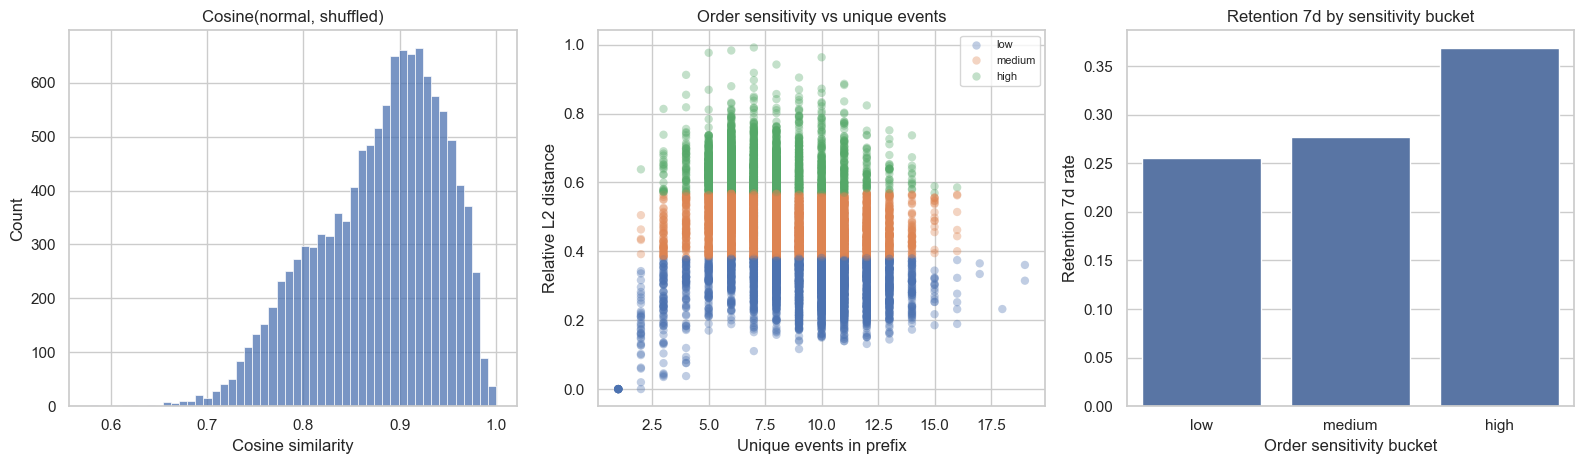

In [6]:
plot_df = to_pandas(bucketed_df.sample(n=min(12000, bucketed_df.height), seed=SEED))
profile_pdf = to_pandas(bucket_profile_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sns.histplot(data=plot_df, x='order_cosine_similarity', bins=50, ax=axes[0])
axes[0].set_title('Cosine(normal, shuffled)')
axes[0].set_xlabel('Cosine similarity')

sns.scatterplot(
    data=plot_df,
    x='unique_event_count',
    y='order_relative_l2_distance',
    hue='order_sensitivity_bucket',
    alpha=0.35,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title('Order sensitivity vs unique events')
axes[1].set_xlabel('Unique events in prefix')
axes[1].set_ylabel('Relative L2 distance')
axes[1].legend(fontsize=8, frameon=True)

sns.barplot(data=profile_pdf, x='order_sensitivity_bucket', y='retention_7d_rate', ax=axes[2])
axes[2].set_title('Retention 7d by sensitivity bucket')
axes[2].set_xlabel('Order sensitivity bucket')
axes[2].set_ylabel('Retention 7d rate')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'order_sensitivity_diagnostics.png', dpi=180)
plt.show()


## Итог

Анализ чувствительности к порядку событий показывает, что обычные и перемешанные `GRU mean` эмбеддинги похожи, но не идентичны. Средняя cosine similarity между эмбеддингами одного и того же пользователя до и после перемешивания prefix равна `0.879`, медианная — `0.889`; 90% пользователей лежат примерно между `0.761` и `0.969`. Средний relative L2 distance равен `0.473`, то есть перемешивание заметно меняет вектор, но не разрушает его полностью.

Самый важный результат виден в bucket profile. Пользователи с низкой sensitivity имеют длинные и повторяющиеся истории: median sequence length `306`, mean repeat ratio `0.901`, mean unique events `9.43`. У high-sensitivity пользователей истории намного короче и разнообразнее: median sequence length `22`, repeat ratio `0.704`, unique events `7.09`. При этом retention rates у high-sensitivity bucket выше: `retention_7d = 0.368` и `retention_14d = 0.266`, против `0.256` и `0.150` у low-sensitivity bucket.

Корреляции подтверждают эту картину. `order_relative_l2_distance` сильнее всего отрицательно связан с `repeat_ratio` (`-0.461`), `prefix_len_feature` (`-0.423`) и `unique_event_count` (`-0.338`). То есть чем длиннее и более повторяющийся prefix, тем меньше порядок влияет на итоговый mean-pooled GRU эмбеддинг. Для коротких и менее повторяющихся early histories перестановка событий меняет representation сильнее.

Это объясняет результат negative controls. В среднем `Shuffled GRU mean` почти не уступает обычному `GRU mean`, потому что у многих пользователей префиксы повторяющиеся, а `усреднение скрытых состояний` дополнительно сглаживает порядок. Но порядок всё же важен для отдельного сегмента пользователей с короткими и менее шаблонными историями. Поэтому честная формулировка такая: текущий RNN эмбеддинг содержит неслучайный поведенческий сигнал, но оценка удержания в основном опирается на состав и режим ранней активности; строгий порядок событий даёт локальный, сегментный, а не глобально устойчивый прирост.